# Wout Calibration — Static Model

This notebook calibrates per-current-point outlet convective transport coefficients (`Wout_c`, `Wout_a`) of the 1D static PEMFC model by fitting the simulated HFR to experimental data across 12 operating conditions. The 9 physical parameters are fixed to their HFR-calibrated values. Each current point has its own Wout_c and Wout_a (7 × 2 = **14 parameters**).

## Setup

Import external libraries and configure the project path so that custom modules (`model`, `configuration`) can be resolved.

In [1]:
import sys
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from hyperopt import fmin, tpe, hp, Trials

warnings.filterwarnings("ignore")

In [ ]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024"
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
# --------------- Import custom modules  --------------- #
import model.static as static_module
from model.static import PEMFC_stat
from model.coefficients import *
from config.initialize import *
from config.settings import *

## Load experimental HFR data

Load all sheets from the HFR Excel file. Each sheet corresponds to one operating condition, named as `T{°C}_P{mbar}_HRC{%}`, with columns `I_LOAD` (A) and `R` (mΩ, full stack).

In [3]:
hfr_data_path = project_root / "data" / "HFR.xlsx"
hfr_testdata = pd.read_excel(hfr_data_path, sheet_name=None)

In [4]:
conditions = {}
for sheet_name, data in hfr_testdata.items():
    parts = sheet_name.split("_")
    Tref = float(parts[0].removeprefix("T")) + 273.15       # °C → K
    Pref = (float(parts[1].removeprefix("P")) / 1e3 + 1) * 1e5      # mbar gauge → Pa abs
    HRref = float(parts[2].removeprefix("HRC")) / 100       # % → fraction

    oi = operating_inputs.copy()
    oi['Tfc'] = Tref
    oi['Pa_des'] = Pref       # Pa
    oi['Pc_des'] = Pref       # Pa
    oi['Phi_a_des'] = HRref
    oi['Phi_c_des'] = HRref
    oi['Win_c'] = 4.8
    oi['Wout_c'] = 4.8     # placeholder, will be overwritten by optimizer
    oi['Win_a'] = 4.8
    oi['Wout_a'] = 4.8     # placeholder

    # Parse the R column: string "(R_value, I_value)" → extract R as float
    parsed = data['R'].str.strip('()').str.split(',', expand=True).astype(float)
    df = pd.DataFrame({'I_LOAD': data['I_LOAD'], 'R': parsed[0]})

    conditions[sheet_name] = {'operating_inputs': oi, 'data': df}

list(conditions.keys())

['T50_P300_HRC0',
 'T50_P300_HRC50',
 'T50_P400_HRC50',
 'T50_P500_HRC50',
 'T60_P300_HRC0',
 'T60_P300_HRC50',
 'T60_P400_HRC50',
 'T60_P500_HRC50',
 'T70_P300_HRC0',
 'T70_P300_HRC50',
 'T70_P400_HRC50',
 'T70_P500_HRC50']

## Define search space

Only `Wout_c` and `Wout_a` per current point (7 × 2 = **14 parameters**). Physical parameters are fixed.

## Apply HFR-calibrated parameters

Load the best parameters obtained from the HFR calibration notebook and apply them to the `parameters` dict. These are kept fixed during the Wout calibration.

In [5]:
# ---- Paste best values from HFR calibration here ---- #
hfr_best = {
    'Re':          3.3e-6,
    'epsilon_gdl': 0.65,
    'epsilon_mc':  0.28,
    'epsilon_cl':  0.32,
    'epsilon_c':   0.23,
    'tau':         1.5,
    'Hmem':        1.5e-5,
    'Hgdl':        3.6e-4,
    'Hcl':         1.3e-5,
}
# Apply to parameters dict
for key, val in hfr_best.items():
    parameters[key] = val
print("HFR-calibrated parameters applied:", list(hfr_best.keys()))

HFR-calibrated parameters applied: ['Re', 'epsilon_gdl', 'epsilon_mc', 'epsilon_cl', 'epsilon_c', 'tau', 'Hmem', 'Hgdl', 'Hcl']


In [6]:
I_points = [10, 20, 30, 35, 40, 45, 50]

params_region = {}
for I in I_points:
    params_region[f"Wout_c_{I}"] = hp.uniform(f'Wout_c_{I}', 5, 25)
    params_region[f"Wout_a_{I}"] = hp.uniform(f'Wout_a_{I}', 5, 10)

print(f"{len(params_region)} parameters: {list(params_region.keys())}")

14 parameters: ['Wout_c_10', 'Wout_a_10', 'Wout_c_20', 'Wout_a_20', 'Wout_c_30', 'Wout_a_30', 'Wout_c_35', 'Wout_a_35', 'Wout_c_40', 'Wout_a_40', 'Wout_c_45', 'Wout_a_45', 'Wout_c_50', 'Wout_a_50']


## Define objective function

The objective minimises the sum of squared errors (SSE) between the **model-predicted HFR** ($R_{\text{ohm}}$) and the **experimental HFR** across all operating conditions and current points, with per-current-point Wout.

$$\text{SSE} = \sum_{\text{cond}} \sum_{I} \left( R_{\text{ohm,pred}}(I) - R_{\text{ohm,exp}}(I) \right)^2$$

In [7]:
Aact = parameters['Aact']
n_cell = parameters['n_cell'] if 'n_cell' in parameters else 22

def obj(params):
    error_sum = 0
    for cond_name, cond in conditions.items():
        df = cond['data']

        for I_LOAD in I_points:
            oi = cond['operating_inputs'].copy()
            oi["Win_a"] = 0
            oi["Win_c"] = 10 + I_LOAD *1.8
            oi["Wout_c"] = params[f'Wout_c_{I_LOAD}']
            oi["Wout_a"] = params[f'Wout_a_{I_LOAD}']

            # Update module-level globals for Pa_des / Pc_des
            static_module.Pa_des = oi['Pa_des']
            static_module.Pc_des = oi['Pc_des']

            model = PEMFC_stat(parameters, oi)
            try:
                sol = model.solve(I_LOAD / Aact)
            except Exception:
                error_sum += 1e6
                continue
            R_pred = sol['Rohm']                                    # Ω·m²
            # R_exp: mΩ (full stack) → Ω·m² per cell = R * 1e-3 / n_cell * Aact
            idx = (df['I_LOAD'] - I_LOAD).abs().idxmin()
            R_exp = df.loc[idx, 'R'] * 1e-3 / n_cell * Aact        # Ω·m²
            error_sum += (R_pred - R_exp) ** 2
    return error_sum

## Initial error check

Run the objective once with default Wout values to verify the function works and to see the starting error magnitude.

In [8]:
init_params = {key: 6.66 for key in params_region}
initial_error = obj(init_params)
print(f"Initial SSE (all Wout=6.66): {initial_error:.6e}")

Initial SSE (all Wout=6.66): 1.713668e-10


## Run hyperopt optimisation

Use the Tree-structured Parzen Estimator (TPE) algorithm from `hyperopt` to search for the Wout pair that minimizes the voltage SSE.

In [9]:
trials = Trials()
best = fmin(fn=obj, space=params_region, algo=tpe.suggest, max_evals=2000, trials=trials)

100%|██████████| 2000/2000 [1:17:35<00:00,  2.33s/trial, best loss: 1.5146103751159646e-10]


In [10]:
print("Best Wout_c per current point:")
for I in I_points:
    print(f"  I={I:2d}A  →  Wout_c={best[f'Wout_c_{I}']:.4f}")
print("\nBest Wout_a per current point:")
for I in I_points:
    print(f"  I={I:2d}A  →  Wout_a={best[f'Wout_a_{I}']:.4f}")
print(f"\nBest SSE: {min(trials.losses()):.6e}")

Best Wout_c per current point:
  I=10A  →  Wout_c=5.0147
  I=20A  →  Wout_c=10.8777
  I=30A  →  Wout_c=24.5631
  I=35A  →  Wout_c=24.9797
  I=40A  →  Wout_c=15.4049
  I=45A  →  Wout_c=8.0376
  I=50A  →  Wout_c=13.1587

Best Wout_a per current point:
  I=10A  →  Wout_a=5.0009
  I=20A  →  Wout_a=7.2952
  I=30A  →  Wout_a=9.2442
  I=35A  →  Wout_a=8.4199
  I=40A  →  Wout_a=6.3071
  I=45A  →  Wout_a=9.3883
  I=50A  →  Wout_a=9.6148

Best SSE: 1.514610e-10


## Plot fitting results

Compare model-predicted HFR (with optimised parameters and per-current-point Wout) against experimental data for all 12 operating conditions.

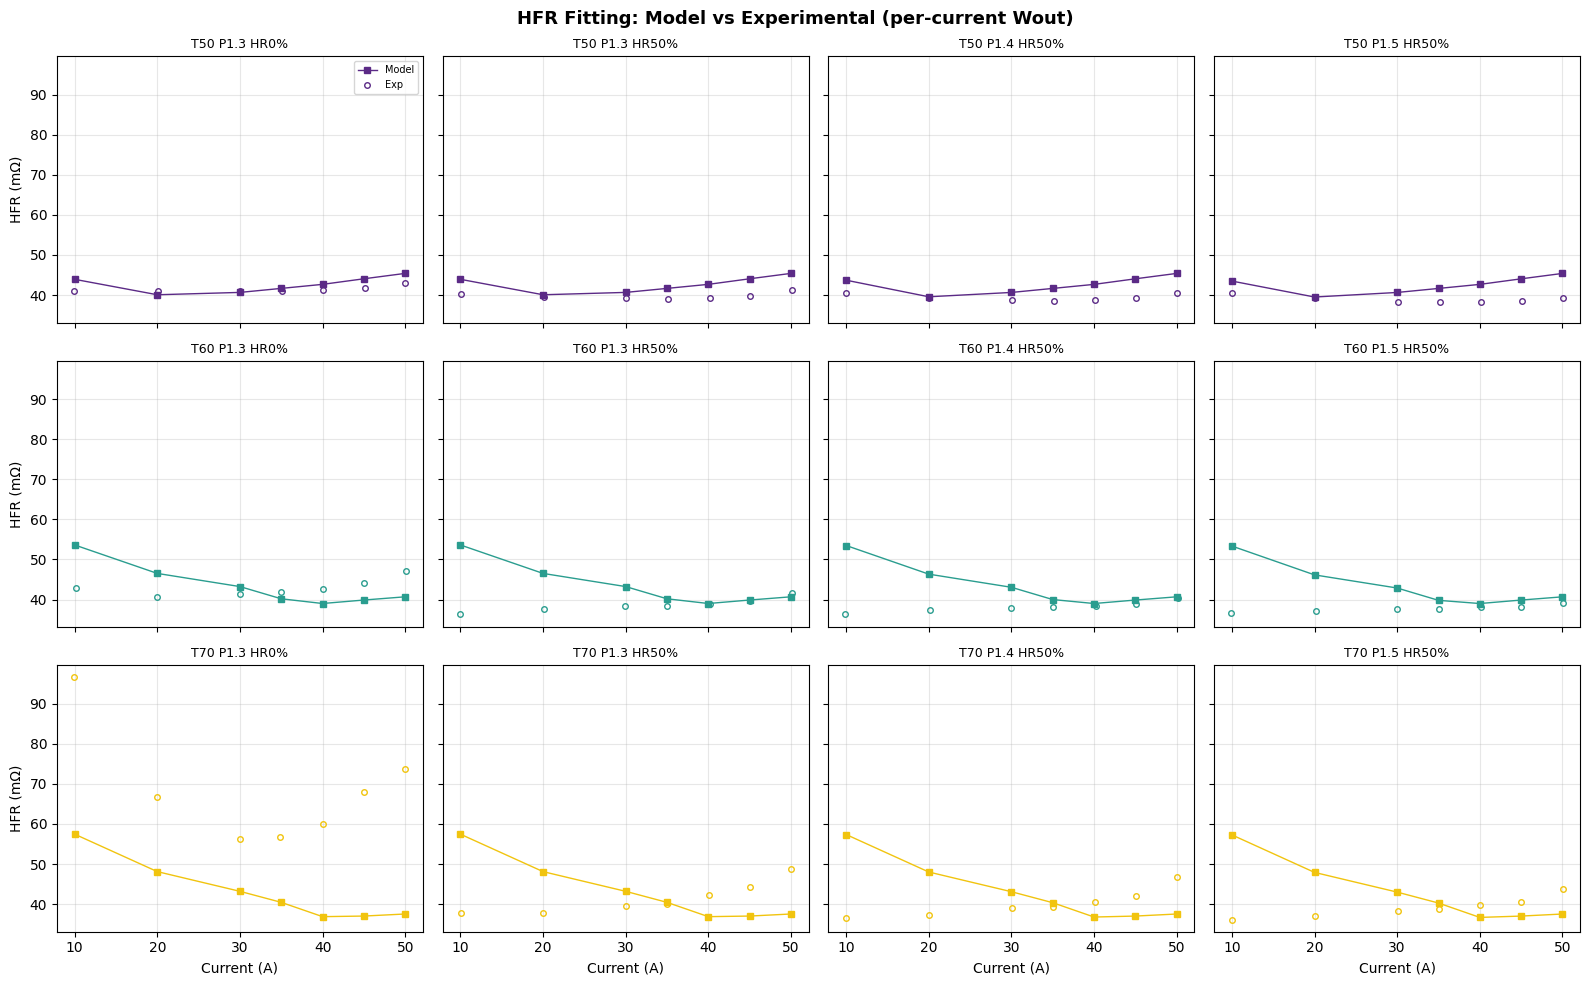

In [11]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for idx, (cond_name, cond) in enumerate(conditions.items()):
    ax = axes[idx]
    df = cond['data']

    # Parse condition label
    parts = cond_name.split("_")
    T_val = float(parts[0].removeprefix("T"))
    P_val = float(parts[1].removeprefix("P")) / 1e3 + 1
    HR_val = float(parts[2].removeprefix("HRC"))

    # Simulate at each current point with its own best Wout
    R_sim = []
    I_valid = []
    for I in I_points:
        oi = cond['operating_inputs'].copy()
        oi["Wout_c"] = best[f'Wout_c_{I}']
        oi["Wout_a"] = best[f'Wout_a_{I}']

        static_module.Pa_des = oi['Pa_des']
        static_module.Pc_des = oi['Pc_des']

        model = PEMFC_stat(parameters, oi)
        try:
            sol = model.solve(I / Aact)
            R_sim.append(sol['Rohm'] / Aact * n_cell * 1e3)  # Ω·m² → mΩ (stack)
            I_valid.append(I)
        except Exception:
            continue

    # Plot
    color = temp_colors.get(T_val, "0.35")
    ax.plot(I_valid, R_sim, 's-', color=color, linewidth=1, markersize=5, label='Model')
    ax.plot(df['I_LOAD'], df['R'], 'o', color=color, markersize=4, markerfacecolor='none', label='Exp')
    ax.set_title(f"T{T_val:.0f} P{P_val:.1f} HR{HR_val:.0f}%", fontsize=9)
    ax.grid(True, alpha=0.3)
    if idx >= 8:
        ax.set_xlabel("Current (A)")
    if idx % 4 == 0:
        ax.set_ylabel("HFR (mΩ)")

axes[0].legend(fontsize=7, loc='upper right')
fig.suptitle("HFR Fitting: Model vs Experimental (per-current Wout)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()